# Goal of the Project

- **Regression**: predict a building's `ENERGYSTARScore` (1–100)
- **Classification**: predict whether the building will **Pass / Fail** Energy Star certification (Pass = Energy Star score ≥ 75)

Feature importance identification from both models can help building owners better understand their Energy Star scores and how to potentially improve them.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import ast

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (r2_score, root_mean_squared_error, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)


# Dataset Preparation

Prior to modelling, we must first understand the data we're working with and prepare it for modelling.

## Understanding the dataset

In [2]:
# Load 2015 Building Energy Benchmarking dataset
df = pd.read_csv("data/2015-building-energy-benchmarking.csv")
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Location,CouncilDistrictCode,Neighborhood,YearBuilt,...,GHGEmissionsIntensity(kgCO2e/ft2),DefaultData,Comment,ComplianceStatus,Outlier,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
0,1,2015,NonResidential,Hotel,MAYFLOWER PARK HOTEL,659000030,"{'latitude': '47.61219025', 'longitude': '-122...",7,DOWNTOWN,1927,...,2.64,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
1,2,2015,NonResidential,Hotel,PARAMOUNT HOTEL,659000220,"{'latitude': '47.61310583', 'longitude': '-122...",7,DOWNTOWN,1996,...,2.38,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
2,3,2015,NonResidential,Hotel,WESTIN HOTEL,659000475,"{'latitude': '47.61334897', 'longitude': '-122...",7,DOWNTOWN,1969,...,1.92,Yes,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,18081
3,5,2015,NonResidential,Hotel,HOTEL MAX,659000640,"{'latitude': '47.61421585', 'longitude': '-122...",7,DOWNTOWN,1926,...,31.38,No,NaN,Compliant,High Outlier,NaN,56.0,NaN,31.0,18081
4,8,2015,NonResidential,Hotel,WARWICK SEATTLE HOTEL,659000970,"{'latitude': '47.6137544', 'longitude': '-122....",7,DOWNTOWN,1980,...,4.02,No,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,19576


In [3]:
# Dataset size
print('Shape of dataset:', df.shape)

# Visualize column data types and percent of missing values
overview = pd.DataFrame({
    'dtype': df.dtypes,
    '%_missing': (df.isna().mean() * 100).round(2),
})
overview

Shape of dataset: (3340, 47)


,dtype,%_missing
OSEBuildingID,int64,0.00
DataYear,int64,0.00
BuildingType,object,0.00
PrimaryPropertyType,object,0.00
PropertyName,object,0.00
TaxParcelIdentificationNumber,object,0.06
Location,object,0.00
CouncilDistrictCode,int64,0.00
Neighborhood,object,0.00
YearBuilt,int64,0.00


In [4]:
# Visualize location column to understand how to handle
df['Location']

0       {'latitude': '47.61219025', 'longitude': '-122...
1       {'latitude': '47.61310583', 'longitude': '-122...
2       {'latitude': '47.61334897', 'longitude': '-122...
3       {'latitude': '47.61421585', 'longitude': '-122...
4       {'latitude': '47.6137544', 'longitude': '-122....
                              ...                        
3335    {'latitude': '47.59950256', 'longitude': '-122...
3336    {'latitude': '47.65752471', 'longitude': '-122...
3337    {'latitude': '47.61649845', 'longitude': '-122...
3338    {'latitude': '47.68396954', 'longitude': '-122...
3339    {'latitude': '47.68396954', 'longitude': '-122...
Name: Location, Length: 3340, dtype: object

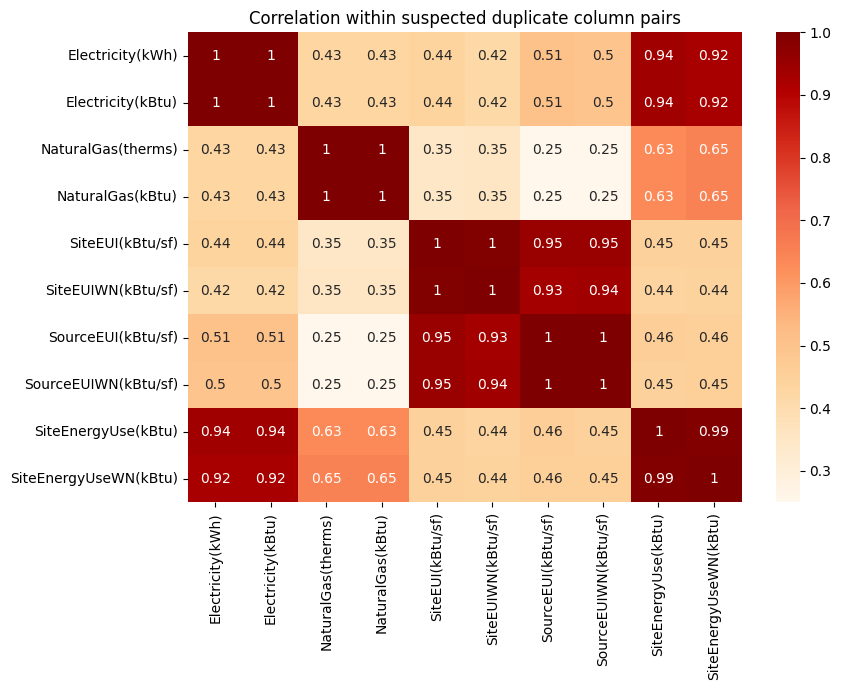

In [5]:
# Noting potential duplicate energy columns (different units)
# Verify correlation for dropping
correlation_check = [
    'Electricity(kWh)', 'Electricity(kBtu)',
    'NaturalGas(therms)', 'NaturalGas(kBtu)',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[correlation_check].corr(), annot=True, cmap='OrRd')
plt.title('Correlation within suspected duplicate column pairs')
plt.tight_layout()
plt.show()

## Dataset cleaning

1. Drop high-missing, identifier, and redundant columns
2. Clean remaining columns:
    - Split `Location` into `latitude` / `longitude`
    - Strip whitespace
3. Clean rows:
    - Remove outliers
    - Remove missing target rows
4. Engineer derived variables (building age, the Pass/Fail target)
5. EDA: distributions and correlations

### Drop high-missing, identifier, and duplicate columns

Groups of columns that carry no predictive value and are removed:

- Mostly empty (>50% missing): 9/47 columns dropped
- Identifiers: building IDs, names, zipcode, tax parcel ID, and arbitrary administrative codes (police beats, council district code, compliance status)
- Duplicates: electricity in kWh (kept in kBtu), natural gas in therms (kept in kBtu), and the weather-normalised copies of the EUI / energy use columns
 - Other useless columns: the constant `DataYear` (we are only looking at 2015 data)

In [6]:
# Outlier column is missing >50% so it will be dropped
# Store the outlier flag before dropping, so flagged rows can be removed later
outlier_flag = df['Outlier'].notna()

# Drop columns that are >50% missing
df = df.dropna(axis=1, thresh=df.shape[0] * 0.50)

# Drop identifiers
identifier_cols = [
    'OSEBuildingID', 'PropertyName', 'TaxParcelIdentificationNumber',
    'ComplianceStatus', 'DefaultData', 'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType', 'CouncilDistrictCode', 'Zip Codes', 'SPD Beats',
    'Seattle Police Department Micro Community Policing Plan Areas',
]

# Drop duplicates
duplicate_cols = [
    'Electricity(kWh)', 'NaturalGas(therms)', 'SiteEUIWN(kBtu/sf)', 
    'SourceEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)',
]

constant_cols = ['DataYear']

df = df.drop(columns=[c for c in identifier_cols + duplicate_cols + constant_cols if c in df.columns])

print(f'\nShape after dropping columns: {df.shape}')

# Display remaining columns and percent missing
print("\nPercent missing:")
df.isna().mean().round(2) * 100


Shape after dropping columns: (3340, 21)

Percent missing:


BuildingType                          0.0
PrimaryPropertyType                   0.0
Location                              0.0
Neighborhood                          0.0
YearBuilt                             0.0
NumberofBuildings                     0.0
NumberofFloors                        0.0
PropertyGFATotal                      0.0
PropertyGFAParking                    0.0
PropertyGFABuilding(s)                0.0
LargestPropertyUseTypeGFA             4.0
ENERGYSTARScore                      23.0
SiteEUI(kBtu/sf)                      0.0
SourceEUI(kBtu/sf)                    0.0
SiteEnergyUse(kBtu)                   0.0
SteamUse(kBtu)                        0.0
Electricity(kBtu)                     0.0
NaturalGas(kBtu)                      0.0
OtherFuelUse(kBtu)                    0.0
GHGEmissions(MetricTonsCO2e)          0.0
GHGEmissionsIntensity(kgCO2e/ft2)     0.0
dtype: float64

In [7]:
# The Location column holds a stringified Python dict
# ast.literal_eval turns each string back into a real dict, then json_normalize expands those dicts into columns
locs = pd.json_normalize(df['Location'].apply(ast.literal_eval))
df[['latitude', 'longitude']] = locs[['latitude', 'longitude']].astype(float)

# The raw Location column can now be dropped
df = df.drop(columns='Location')

df[['latitude', 'longitude']]

,latitude,longitude
0,47.612190,-122.337997
1,47.613106,-122.333358
2,47.613349,-122.337699
3,47.614216,-122.336609
4,47.613754,-122.340924
...,...,...
3335,47.599503,-122.320343
3336,47.657525,-122.316016
3337,47.616498,-122.337708
3338,47.683970,-122.287409


In [8]:
# Clean remaining text columns (strip whitespace)
text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())

### Handle the target

`ENERGYSTARScore` is the regression target, so rows where it is missing (~23%) cannot be used for training. These rows will be dropped, along with rows flagged as outliers and any rows with impossible values (e.g., zero or negative energy use).

In [9]:
# Visualize statistics of numeric rows to better understand any processing required on rows
df.select_dtypes('number').describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),latitude,longitude
count,3340.000000,3340.000000,3332.000000,3.340000e+03,3340.000000,3.340000e+03,3.204000e+03,2560.000000,3330.000000,3330.000000,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3330.000000,3330.000000,3340.000000,3340.000000
mean,1967.624850,1.035629,4.682173,9.077289e+04,11054.032335,7.971886e+04,7.488154e+04,67.894141,53.626126,132.779730,4.983106e+06,2.502851e+05,3.473209e+06,1.253304e+06,7.142301e+03,110.094102,0.985339,47.624091,-122.335013
std,32.949847,0.784463,5.458460,1.493058e+05,35296.330507,1.292314e+05,1.236249e+05,27.154057,53.893311,131.943223,1.375330e+07,3.481900e+06,9.519639e+06,4.415142e+06,1.962790e+05,409.450179,1.637172,0.047924,0.027169
min,1900.000000,1.000000,0.000000,2.000000e+04,-3.000000,-5.055000e+04,5.872000e+03,1.000000,0.000000,-2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,47.499331,-122.413996
25%,1947.000000,1.000000,2.000000,2.848700e+04,0.000000,2.668300e+04,2.500000e+04,51.750000,27.300000,73.500000,9.139300e+05,0.000000e+00,6.363322e+05,0.000000e+00,0.000000e+00,9.265000,0.080000,47.599836,-122.350568
50%,1973.000000,1.000000,4.000000,4.385500e+04,0.000000,4.132600e+04,3.900000e+04,76.000000,37.400000,95.000000,1.776219e+06,0.000000e+00,1.160236e+06,2.945770e+05,0.000000e+00,32.740000,0.460000,47.618496,-122.332712
75%,1996.000000,1.000000,5.000000,8.842800e+04,4304.250000,7.872600e+04,7.206750e+04,90.000000,59.875000,143.900000,4.044277e+06,0.000000e+00,2.750847e+06,1.115366e+06,0.000000e+00,88.642500,1.180000,47.657223,-122.319898
max,2015.000000,39.000000,99.000000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,100.000000,800.600000,2511.100000,2.958126e+08,1.278697e+08,2.847263e+08,1.364484e+08,8.269669e+06,11824.890000,31.380000,47.733811,-122.220470


In [10]:
original_rows = len(df)

# Drop city-flagged outliers
df = df[~outlier_flag]
n_rows = len(df)
print(f'Dropped {original_rows - n_rows} city-flagged outlier rows')

# Drop rows with no target (can't train on a missing label)
df = df[df['ENERGYSTARScore'].notna()]
new_rows = len(df)
print(f'Dropped {n_rows - new_rows} rows with missing ENERGYSTARScore')

# Drop physically impossible values (zero or negative physical factors / energy use in buildings with > 0 GFA)
df = df[
    (df['PropertyGFATotal'] > 0) &
    (df['PropertyGFABuilding(s)'] >= 0) &
    (df['PropertyGFAParking'] >= 0) &
    (df['SiteEUI(kBtu/sf)'] >= 0) &
    (df['SourceEUI(kBtu/sf)'] >= 0) &
    (df['SiteEnergyUse(kBtu)'] >= 0)
]
print(f'Dropped {new_rows - len(df)} rows with impossible values')

print(f'\nFinal row count: {len(df)}')

# Make note of remaining missing values for future imputation
df.isna().sum()

Dropped 84 city-flagged outlier rows
Dropped 765 rows with missing ENERGYSTARScore
Dropped 3 rows with impossible values

Final row count: 2488


BuildingType                           0
PrimaryPropertyType                    0
Neighborhood                           0
YearBuilt                              0
NumberofBuildings                      0
NumberofFloors                         3
PropertyGFATotal                       0
PropertyGFAParking                     0
PropertyGFABuilding(s)                 0
LargestPropertyUseTypeGFA            107
ENERGYSTARScore                        0
SiteEUI(kBtu/sf)                       0
SourceEUI(kBtu/sf)                     0
SiteEnergyUse(kBtu)                    0
SteamUse(kBtu)                         0
Electricity(kBtu)                      0
NaturalGas(kBtu)                       0
OtherFuelUse(kBtu)                     0
GHGEmissions(MetricTonsCO2e)           0
GHGEmissionsIntensity(kgCO2e/ft2)      0
latitude                               0
longitude                              0
dtype: int64

### Feature engineering

- Building age is more interpretable than year built: `building_age` = 2015 − `YearBuilt`
- Classification target (pass/fail) should be derived from `ENERGYSTARScore` (pass >= 75, as per the EPA's official threshold for ENERGY STAR certification)

In [11]:
# Building age (the benchmarking data year is 2015)
df['building_age'] = 2015 - df['YearBuilt']
df = df.drop(columns='YearBuilt')

# Classification target: Pass / Fail at the ENERGY STAR certification threshold (>= 75)
PASS_THRESHOLD = 75
df['ENERGYSTARCertification'] = np.where(df['ENERGYSTARScore'] >= PASS_THRESHOLD, 'Pass', 'Fail')

# Visualize class balance
(df['ENERGYSTARCertification'].value_counts(normalize=True) * 100).round(1)

ENERGYSTARCertification
Pass    51.2
Fail    48.8
Name: proportion, dtype: float64

## EDA

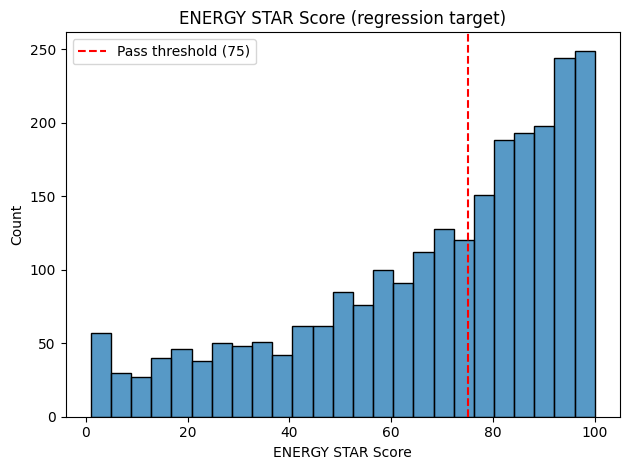

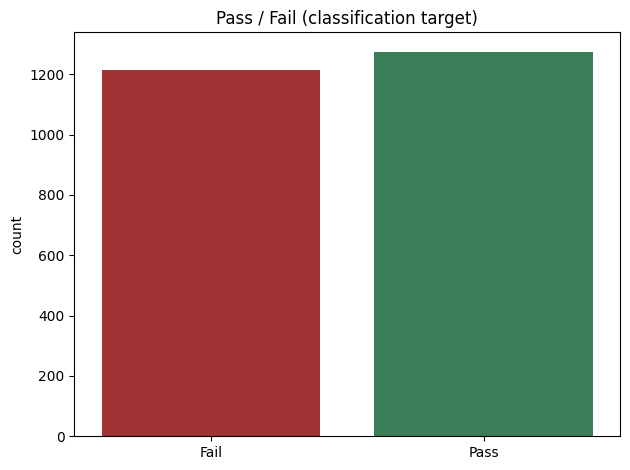

In [12]:
# Regression target: ENERGY STAR Score distribution
sns.histplot(df['ENERGYSTARScore'], bins=25)
plt.axvline(PASS_THRESHOLD, color='red', linestyle='--', label=f'Pass threshold ({PASS_THRESHOLD})')
plt.title('ENERGY STAR Score (regression target)')
plt.xlabel('ENERGY STAR Score')
plt.legend()
plt.tight_layout()
plt.show()

# Classification target: Pass / Fail balance
sns.countplot(x='ENERGYSTARCertification', data=df, hue='ENERGYSTARCertification', palette={'Fail': 'firebrick', 'Pass': 'seagreen'})
plt.title('Pass / Fail (classification target)')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [13]:
# Visualize skew
num = df.select_dtypes('number').drop(columns=['ENERGYSTARScore'])

num.skew().round(1).sort_values(ascending=False)

OtherFuelUse(kBtu)                   35.3
NumberofBuildings                    30.1
SteamUse(kBtu)                       28.9
NaturalGas(kBtu)                     19.7
GHGEmissions(MetricTonsCO2e)         19.1
Electricity(kBtu)                    14.6
SiteEnergyUse(kBtu)                  13.7
SourceEUI(kBtu/sf)                    8.5
SiteEUI(kBtu/sf)                      6.1
LargestPropertyUseTypeGFA             6.0
PropertyGFABuilding(s)                5.8
PropertyGFAParking                    5.8
NumberofFloors                        5.7
PropertyGFATotal                      5.6
GHGEmissionsIntensity(kgCO2e/ft2)     3.1
building_age                          0.6
latitude                              0.1
longitude                            -0.1
dtype: float64

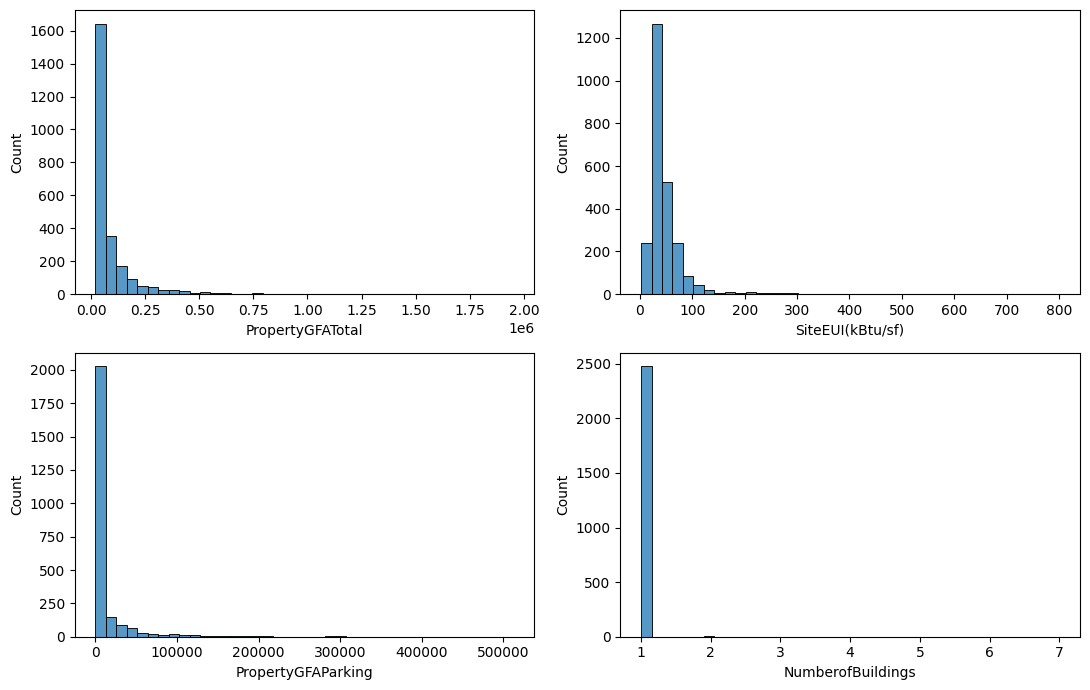

In [14]:
# Plot some of the skewed features to identify future transformations required
skewed = ['PropertyGFATotal', 'SiteEUI(kBtu/sf)', 'PropertyGFAParking', 'NumberofBuildings']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flatten(), skewed):
    sns.histplot(df[col], bins=40, ax=ax)
plt.tight_layout()
plt.show()

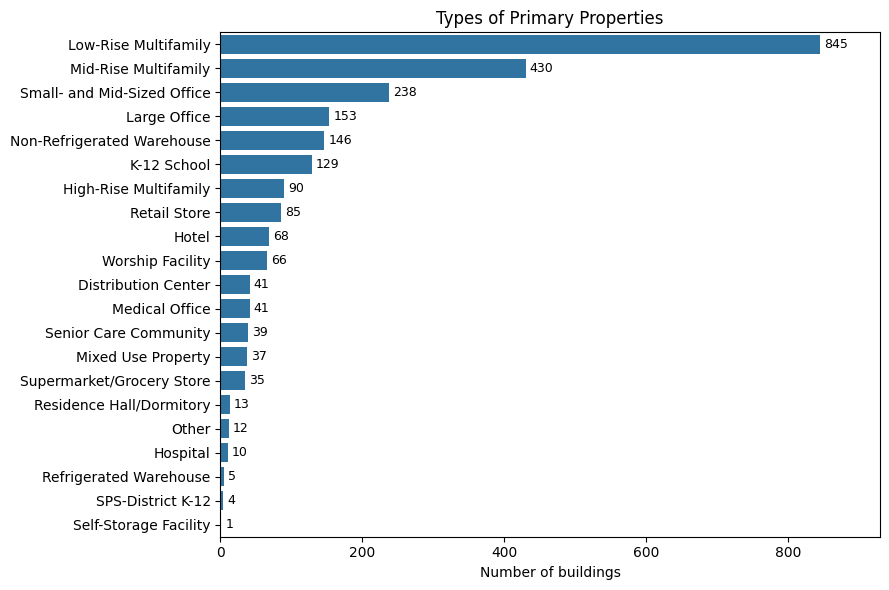

In [15]:
# Visualize PrimaryPropertyType frequencies to see the distribution of categories
counts = df['PrimaryPropertyType'].value_counts()
plt.figure(figsize=(9,6))
ax = sns.barplot(x=counts.values, y=counts.index)

# Value label at the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
ax.margins(x=0.1)  # extra room so the labels aren't clipped

plt.xlabel('Number of buildings')
plt.ylabel('')
plt.title('Types of Primary Properties')
plt.tight_layout()
plt.show()

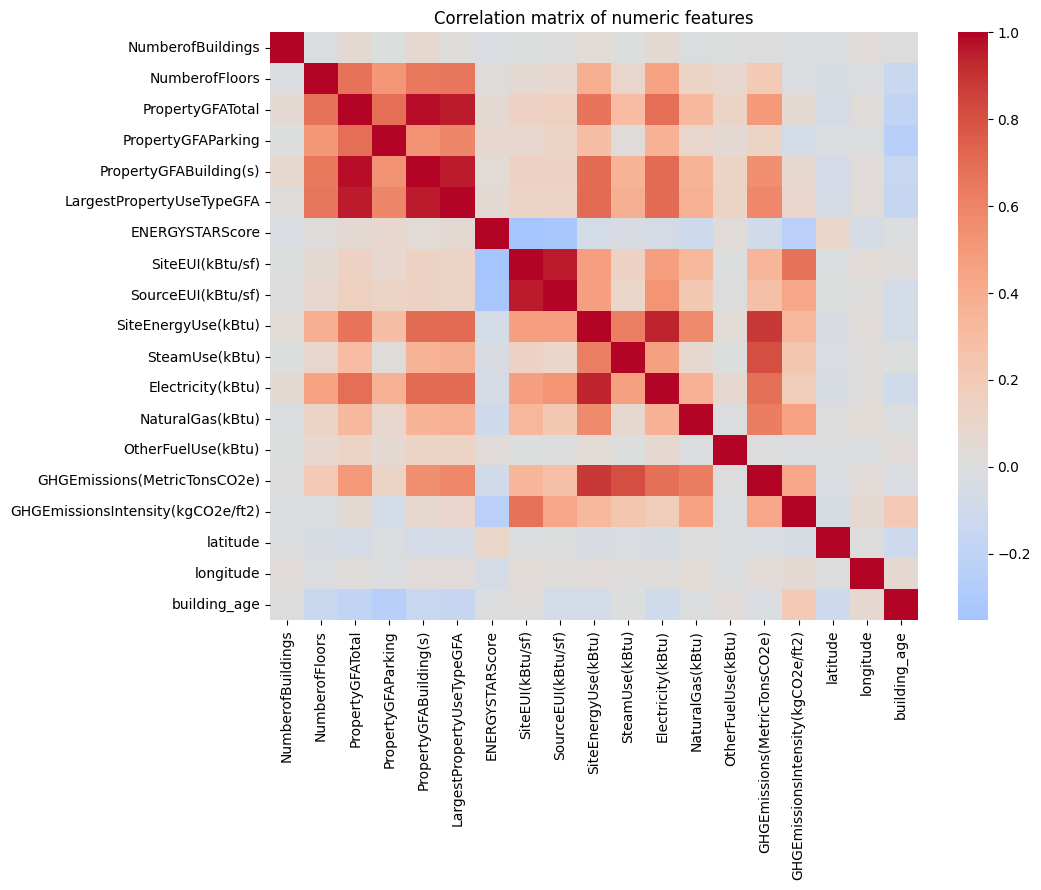

Correlation with ENERGYSTARScore:
SiteEUI(kBtu/sf)                     0.352734
SourceEUI(kBtu/sf)                   0.339566
GHGEmissionsIntensity(kgCO2e/ft2)    0.233007
latitude                             0.103177
NaturalGas(kBtu)                     0.099446
PropertyGFAParking                   0.084144
GHGEmissions(MetricTonsCO2e)         0.083668
SiteEnergyUse(kBtu)                  0.076705
PropertyGFATotal                     0.058207
longitude                            0.056611
LargestPropertyUseTypeGFA            0.055278
Electricity(kBtu)                    0.054580
PropertyGFABuilding(s)               0.045117
SteamUse(kBtu)                       0.033658
NumberofBuildings                    0.024997
OtherFuelUse(kBtu)                   0.024150
NumberofFloors                       0.012902
building_age                         0.010967
Name: ENERGYSTARScore, dtype: float64


In [16]:
# Visualize correlation among numeric features and the regression target
num_for_corr = df.select_dtypes(include='number')

plt.figure(figsize=(11, 9))
sns.heatmap(num_for_corr.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

print('Correlation with ENERGYSTARScore:')
print(num_for_corr.corr()['ENERGYSTARScore'].abs().drop('ENERGYSTARScore').sort_values(ascending=False))

# Predictive Modelling

For the sake of applying both types of modelling learned in this course, this project will demonstrate two **independent** supervised learning exercises on the cleaned data (the classification target is directly derived from the regression target):

| Exercise | Target | Type | Model(s) |
|---|---|---|---|
| **Regression** | `ENERGYSTARScore` (1–100) | continuous | Ridge Regression vs Gradient-Boosting Regressor
| **Classification** | Pass / Fail (score ≥ 75) | binary | Logistic Regression vs Random Forest |

One of the goals of this project is to understand which factors drive the Energy Star score, so I've selected interpretable models with readable coefficients / importances. Ridge is chosen over plain linear regression because the energy features are mutually correlated (multicollinearity) as seen in the EDA above. Ridge's L2 penalty shrinks correlated coefficients together and stabilises them while keeping every feature in the model. Gradient-Boosting is also used to compare performance. For classification, I've chosen to test an interpretable linear baseline (Logistic Regression) with a non-linear Random Forest to see whether interactions improve accuracy.

PCA was not done for this exercise since it removes feature interpretability which inhibits extracting feature importance.

## Preprocessing

Each model is wrapped in a shared preprocessor fit on the training set only to prevent data leakage:
- `SimpleImputer` to impute the few missing remaining values
- `PowerTransformer` (Yeo-Johnson) on the numeric features to correct the heavy right-skew seen in the EDA and standardises in one step
- `OneHotEncoder` for the 3 categorical features
- `RareCategoryGrouper` to group rare primary property type categories seen in the EDA

In [17]:
# Create features matrix (drop the two independent targets)
X = df.drop(columns=['ENERGYSTARScore', 'ENERGYSTARCertification'])

# Regression target (1-100)
y_reg = df['ENERGYSTARScore']

# Classification target ('Pass' / 'Fail' labels)
y_clf = df['ENERGYSTARCertification']

# Capture categorical and numerical columns for transformation
categorical_feats = X.select_dtypes('object').columns.tolist()
numeric_feats = X.select_dtypes('number').columns.tolist()

# Custom transformer to group small primary property types into "Other" to reduce noise and variance
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Group infrequent categories into 'Other'. The 'frequent' list is learned from
    TRAIN only (fit), so it is leak-free; rare OR unseen categories at transform map to 'Other'."""
    def __init__(self, columns, min_count=15, other_label='Other'):
        self.columns = columns
        self.min_count = min_count
        self.other_label = other_label

    def fit(self, X, y=None):
        self.frequent_ = {
            col: X[col].value_counts().loc[lambda s: s >= self.min_count].index
            for col in self.columns
        }
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].where(X[col].isin(self.frequent_[col]), self.other_label)
        return X


# Create preprocessor column transformation
def make_preprocess():
    numeric = Pipeline([
        # Use median because of heavy right-skew in data
        ('impute', SimpleImputer(strategy='median')),
        ('power',  PowerTransformer(method='yeo-johnson', standardize=True)),
    ])
    column_tf = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_feats),
        ('num', numeric, numeric_feats),
    ])
    # Do rare-category grouping first, then column transformation
    return Pipeline([
        ('group', RareCategoryGrouper(columns=['PrimaryPropertyType'], min_count=15)),
        ('ct', column_tf),
    ])

## Regression: predicting the ENERGY STAR Score

Two models compared:

- Ridge selected because the dataset contains significant multicollinearity and the L2 penalty handles this well. Specifically, it was selected over Lasso since it keeps every feature and distributes the weight across correlated ones stably. RidgeCV is used to select the best regularization strength.
- Gradient-Boosting selected for potential performance improvement (capturing non-linear relationships missed by Ridge)

In [18]:
# Train/test split for regression
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Ridge with the regularisation strength chosen by cross-validation (logspace for alphas to test broader range of parameters more efficiently)
# Create pipeline to ensure transformation is properly handled with cross-validation splits (no data leakage)
ridge = Pipeline([
    ('prep', make_preprocess()),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 50))),
])

# Fit on training set
ridge.fit(Xr_train, yr_train)

# Perform cross validation to evaluate model performance before final scoring
cv_r2 = cross_val_score(ridge, Xr_train, yr_train, cv=5, scoring='r2')

print(f'Best alpha: {ridge.named_steps["model"].alpha_:.3g}')
print(f'5-fold CV R2: {cv_r2.mean():.3f}')


Best alpha: 0.121
5-fold CV R2: 0.466


In [19]:
# Predict on test set
pred_r = ridge.predict(Xr_test)

# Overfitting check: train vs test R2
print(f'Train R2: {ridge.score(Xr_train, yr_train):.3f}')
print(f'Test R2: {r2_score(yr_test, pred_r):.3f}')

# Test error in score points
print(f'\nTest RMSE (score pts): {root_mean_squared_error(yr_test, pred_r):.2f}')
print(f'Test MAE (score pts): {mean_absolute_error(yr_test, pred_r):.2f}')

Train R2: 0.506
Test R2: 0.504

Test RMSE (score pts): 19.31
Test MAE (score pts): 14.47


**Performance Evaluation**

The model performs moderately. With an R2 of 0.5, only half the variation in scores is explained, but it's better than predicting the average score. The gap in RMSE and MAE shows that the predictions are skewed by a few large errors. With the RMSE at ~19 score points, I would conclude that the model can be used as a rough ranking, but not precise enough for confident individual predictions.

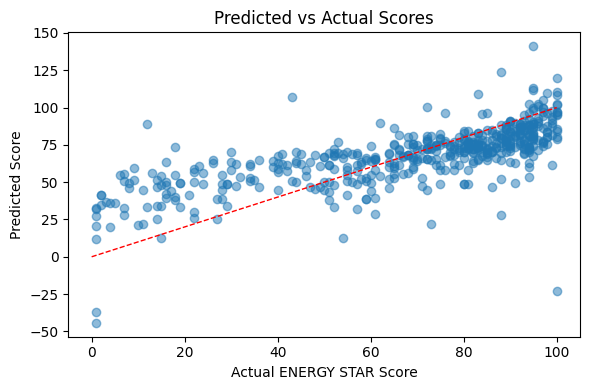

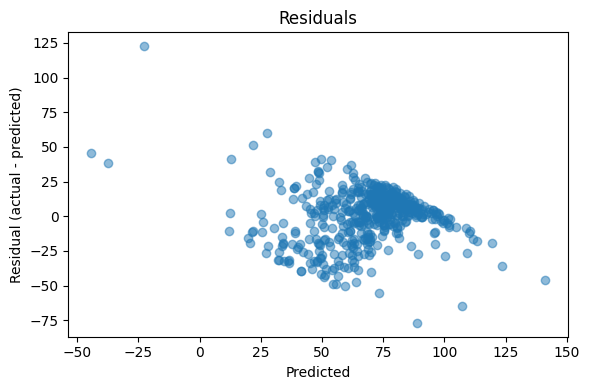

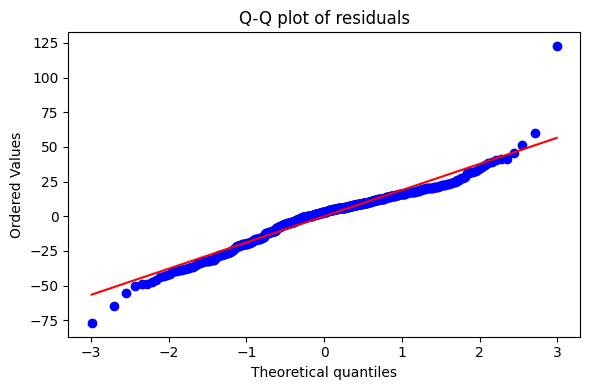

In [20]:
# Predicted vs actual
plt.figure(figsize=(6, 4))
plt.scatter(yr_test, pred_r, alpha=0.5)
plt.plot([0, 100], [0, 100], 'r--', linewidth=1)
plt.xlabel('Actual ENERGY STAR Score'); 
plt.ylabel('Predicted Score')
plt.title('Predicted vs Actual Scores')
plt.tight_layout();
plt.show()

# Plot residuals to verify homoskedasticity
residual = yr_test - pred_r
plt.figure(figsize=(6, 4))
plt.scatter(pred_r, residual, alpha=0.5)
plt.xlabel('Predicted'); 
plt.ylabel('Residual (actual - predicted)')
plt.title('Residuals')
plt.tight_layout(); 
plt.show()

# QQ plot to validate normal distribution of residuals
fig, ax = plt.subplots(figsize=(6, 4))
_, (_, _, r) = sp.stats.probplot(residual, plot=ax, fit=True)
ax.set_title('Q-Q plot of residuals')
plt.tight_layout(); 
plt.show()

The QQ plot above shows that while the residuals are roughly symmetric, there are outliers at both ends, confirming that most of the errors are small, but there are a few large ones that are causing less than optimal results. We can also see heteroskedasticity from the residuals vs predicted plot, which shows that there are non-linear relationships being missed by the model. This is also reflected in the predicted vs actuals plot.

In [21]:
# Identify top 15 drivers of the predicted Energy Star Score
# Capture transformed feature names and extract related coefficients
feature_names = ridge.named_steps['prep'].named_steps['ct'].get_feature_names_out()
coef_table = pd.DataFrame({'Predictor': feature_names, 'coefficient': ridge.named_steps['model'].coef_.round(4)})

# Sort by absolute value of coefficient
coef_table.sort_values('coefficient', key=abs, ascending=False, ignore_index=True).head(15)

,Predictor,coefficient
0,cat__PrimaryPropertyType_Supermarket/Grocery S...,76.8305
1,cat__PrimaryPropertyType_Large Office,53.3725
2,cat__PrimaryPropertyType_Small- and Mid-Sized ...,45.9965
3,cat__PrimaryPropertyType_Retail Store,45.5168
4,cat__PrimaryPropertyType_Mid-Rise Multifamily,45.3166
5,cat__PrimaryPropertyType_Senior Care Community,43.7191
6,cat__PrimaryPropertyType_Mixed Use Property,43.5485
7,cat__PrimaryPropertyType_Other,41.5047
8,cat__PrimaryPropertyType_High-Rise Multifamily,38.6984
9,cat__PrimaryPropertyType_Medical Office,37.9740


The coefficient chart highlights the main drivers of the predicted score, where positive values raise the score and negative values decrease it (with all other features held constant).

In [22]:
# Gradient Boosting Regressor on the same pipeline and train/test split as Ridge
gbr = Pipeline([
    ('prep', make_preprocess()),
    ('model', GradientBoostingRegressor(random_state=42)),
])
gbr.fit(Xr_train, yr_train)

gbr_cv_r2 = cross_val_score(gbr, Xr_train, yr_train, cv=5, scoring='r2')
gbr_pred = gbr.predict(Xr_test)

# Compare Ridge vs Gradient Boosting
reg_compare = pd.DataFrame({
    'Ridge': {
        'Train R2': ridge.score(Xr_train, yr_train),
        'CV R2':    cv_r2.mean(),
        'Test R2':  r2_score(yr_test, pred_r),
        'Test RMSE': root_mean_squared_error(yr_test, pred_r),
        'Test MAE':  mean_absolute_error(yr_test, pred_r),
    },
    'Gradient Boosting': {
        'Train R2': gbr.score(Xr_train, yr_train),
        'CV R2':    gbr_cv_r2.mean(),
        'Test R2':  r2_score(yr_test, gbr_pred),
        'Test RMSE': root_mean_squared_error(yr_test, gbr_pred),
        'Test MAE':  mean_absolute_error(yr_test, gbr_pred),
    },
}).round(3)
reg_compare

,Ridge,Gradient Boosting
Train R2,0.506,0.689
CV R2,0.466,0.543
Test R2,0.504,0.632
Test RMSE,19.310,16.619
Test MAE,14.468,12.034


**Comparison Analysis:** 

Gradient Boosting raises the test R2 from **0.50 to 0.63** and cuts error from RMSE ~19.3 to ~16.6 score points. This confirms that there is meaningful non-linearity and feature interactions that Ridge could not capture.

That said, an R2 of 0.63 is still not ideal, so non-linearity was not the only inhibiting factor. From research, it seems there are key operational variables missing in this dataset that would improve the prediction performance (ie operating hours, occupancy, etc). The score is also calculated on a **comparison basis** by primary property type, so while Gradient Boosting captures these feature interactions, it could be further improved by adding a feature that explains relative_EUI within its property type. This would give it the added information of a property type’s mean EUI and standard deviation, giving a clearer picture of peer comparison.

## Classification: predicting Pass / Fail certification

Two models compared:
- **Logistic Regression** as an interpretable linear baseline (coefficients are the log-odds of passing)
- **Random Forest** to test whether non-linearity & capturing feature interactions will improve the results, while still providing feature importances

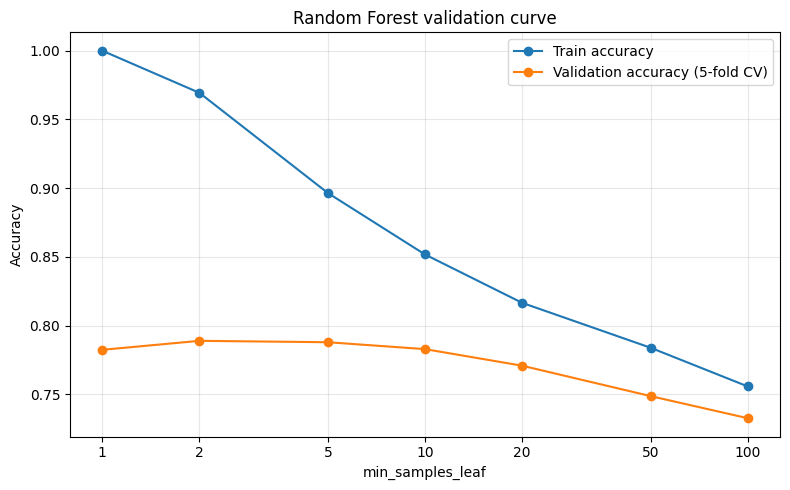

,min_samples_leaf,Train Acc,Validation Acc,Gap
0,1,1.000,0.782,0.218
1,2,0.969,0.789,0.180
2,5,0.896,0.788,0.109
3,10,0.852,0.783,0.069
4,20,0.817,0.771,0.046
5,50,0.784,0.749,0.035
6,100,0.756,0.733,0.023


In [23]:
# Train/test split for classification
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Numeric test labels for the ROC-AUC metric (positive class = Pass)
yc_test_pass = (yc_test == 'Pass').astype(int)

# Plot train vs CV accuracy at different min_samples_leaf to find optimal value to prevent overfitting
leaf_range = [1, 2, 5, 10, 20, 50, 100]

train_mean, val_mean = [], []
for leaf in leaf_range:
    rf_optimization = Pipeline([('prep', make_preprocess()),
                      ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, random_state=42))])
    
    # Fit and score on training set
    rf_optimization.fit(Xc_train, yc_train)
    train_mean.append(rf_optimization.score(Xc_train, yc_train))

    # CV accuracy via 5-fold cross-validation
    val_mean.append(cross_val_score(rf_optimization, Xc_train, yc_train, cv=5).mean())

train_mean, val_mean = np.array(train_mean), np.array(val_mean)

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.plot(leaf_range, train_mean, 'o-', label='Train accuracy')
ax.plot(leaf_range, val_mean, 'o-', label='Validation accuracy (5-fold CV)')
ax.set_xscale('log')
ax.set_xticks(leaf_range)
ax.set_xticklabels(leaf_range)
ax.minorticks_off()
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest validation curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Numbers behind the curve, including the train-validation gap
vc_table = pd.DataFrame({'min_samples_leaf': leaf_range,
                         'Train Acc': train_mean.round(3),
                         'Validation Acc': val_mean.round(3),
                         'Gap': (train_mean - val_mean).round(3)})
vc_table

**Controlling Random Forest overfitting**

To prevent overfitting (the model memorizing all the training data), tree complexity is constrained by selecting a min_samples_leaf value that minimizes the training validation gap, but maintains decent validation accuracy. From the plot & chart above, this value is selected to be 10.

In [24]:
# Logistic Regression
# max_iter=1000 to ensure convergence
logreg = Pipeline([
    ('prep', make_preprocess()),
    ('model', LogisticRegression(max_iter=1000))
])

# Fit on training set
logreg.fit(Xc_train, yc_train)

# Capture the probability column for the 'Pass' class
pass_prob = list(logreg.classes_).index('Pass')

# Predict on test set and capture probabilities of passing
log_pred  = logreg.predict(Xc_test)
log_proba = logreg.predict_proba(Xc_test)[:, pass_prob]

# Save evaluation metrics
log_metrics = {
    'Accuracy': accuracy_score(yc_test, log_pred),
    'Precision': precision_score(yc_test, log_pred, pos_label='Pass'),
    'Recall': recall_score(yc_test, log_pred, pos_label='Pass'),
    'F1': f1_score(yc_test, log_pred, pos_label='Pass'),
    'ROC-AUC': roc_auc_score(yc_test_pass, log_proba),
}
log_metrics

{'Accuracy': 0.8012048192771084,
 'Precision': 0.7977941176470589,
 'Recall': 0.8314176245210728,
 'F1': 0.8142589118198874,
 'ROC-AUC': 0.8736117173480771}

In [25]:
# Random Forest
# n_estimators=300 for stable averaging, min_samples_leaf=10 chosen from validation curve above
rf = Pipeline([
    ('prep', make_preprocess()),
    ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42))
])

# Fit on training set
rf.fit(Xc_train, yc_train)

# Capture the probability column for the 'Pass' class
pass_prob = list(rf.classes_).index('Pass')

# Predict on test set and capture probabilities of passing
rf_pred  = rf.predict(Xc_test)
rf_proba = rf.predict_proba(Xc_test)[:, pass_prob]

# Save evaluation metrics
rf_metrics = {
    'Accuracy': accuracy_score(yc_test, rf_pred),
    'Precision': precision_score(yc_test, rf_pred, pos_label='Pass'),
    'Recall': recall_score(yc_test, rf_pred, pos_label='Pass'),
    'F1': f1_score(yc_test, rf_pred, pos_label='Pass'),
    'ROC-AUC': roc_auc_score(yc_test_pass, rf_proba),
}
rf_metrics

{'Accuracy': 0.821285140562249,
 'Precision': 0.8115942028985508,
 'Recall': 0.8582375478927203,
 'F1': 0.8342644320297952,
 'ROC-AUC': 0.8906671839888776}

In [26]:
# Combine both models' metrics into one comparison table
clf_results = pd.DataFrame({'Logistic Regression': log_metrics, 'Random Forest': rf_metrics}).round(3)
clf_results

,Logistic Regression,Random Forest
Accuracy,0.801,0.821
Precision,0.798,0.812
Recall,0.831,0.858
F1,0.814,0.834
ROC-AUC,0.874,0.891


In [27]:
# Overfitting check: train vs test accuracy
overfit = {}
for name, pipe, test_score in [
    ('Logistic Regression', logreg, log_metrics['Accuracy']),
    ('Random Forest', rf, rf_metrics['Accuracy']),
]:
    train_score = accuracy_score(yc_train, pipe.predict(Xc_train))
    overfit[name] = {'Train Accuracy': train_score, 'Test Accuracy': test_score}

pd.DataFrame(overfit).round(3)

,Logistic Regression,Random Forest
Train Accuracy,0.804,0.852
Test Accuracy,0.801,0.821


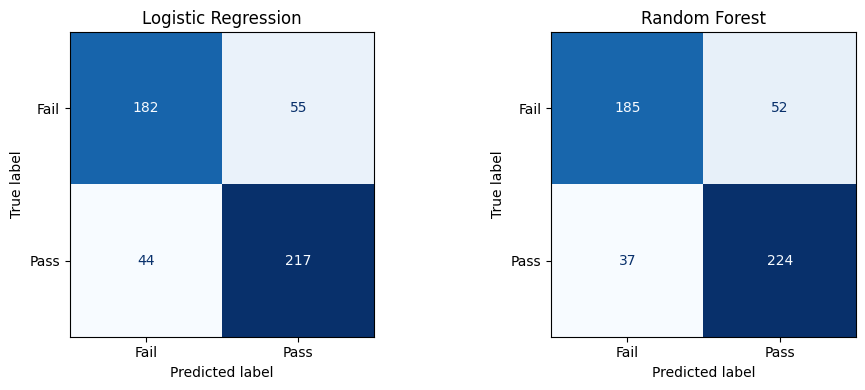

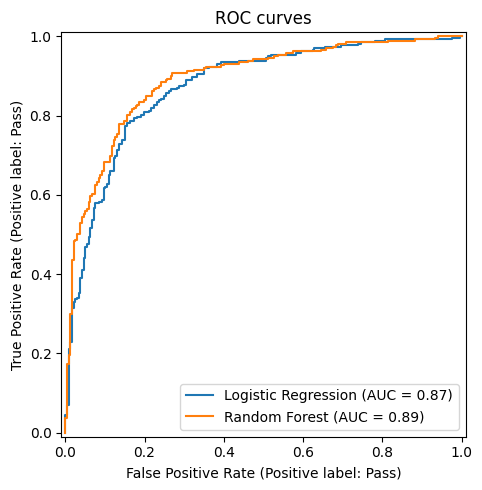

In [28]:
# Visualize confusion matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(logreg, Xc_test, yc_test, display_labels=['Fail', 'Pass'],
                                      cmap='Blues', colorbar=False, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_estimator(rf, Xc_test, yc_test, display_labels=['Fail', 'Pass'],
                                      cmap='Blues', colorbar=False, ax=axes[1])
axes[1].set_title('Random Forest')
plt.tight_layout(); 
plt.show()

# Plot ROC curves for Pass class
plt.figure(figsize=(6, 5))
ax = plt.gca()
RocCurveDisplay.from_estimator(logreg, Xc_test, yc_test, name='Logistic Regression', pos_label='Pass', ax=ax)
RocCurveDisplay.from_estimator(rf, Xc_test, yc_test, name='Random Forest', pos_label='Pass', ax=ax)
ax.set_title('ROC curves')
plt.tight_layout(); 
plt.show()

In [29]:
# Identify top 15 drivers of the predicted passing classification
# Capture transformed feature names and extract related coefficients
feature_names = logreg.named_steps['prep'].named_steps['ct'].get_feature_names_out()
coef_table = pd.DataFrame({'Predictor': feature_names, 'coefficient': logreg.named_steps['model'].coef_[0].round(4)})

# Sort by absolute value of coefficient
coef_table.sort_values('coefficient', key=abs, ascending=False, ignore_index=True).head(15)

,Predictor,coefficient
0,cat__PrimaryPropertyType_Supermarket/Grocery S...,4.5059
1,cat__PrimaryPropertyType_Non-Refrigerated Ware...,-2.9862
2,cat__PrimaryPropertyType_Worship Facility,-2.3595
3,cat__PrimaryPropertyType_Large Office,2.3402
4,cat__PrimaryPropertyType_Small- and Mid-Sized ...,1.7569
5,cat__PrimaryPropertyType_Retail Store,1.6394
6,num__SourceEUI(kBtu/sf),-1.4422
7,num__GHGEmissions(MetricTonsCO2e),1.2653
8,num__SiteEUI(kBtu/sf),-1.1045
9,cat__PrimaryPropertyType_Senior Care Community,1.0525


In [30]:
# Identify top 15 drivers from Random Forest
# Capture transformed feature names and extract related feature importances
feature_names = rf.named_steps['prep'].named_steps['ct'].get_feature_names_out()
importance_table = pd.DataFrame({'Predictor': feature_names, 'importance': rf.named_steps['model'].feature_importances_.round(4)})

# Sort by importance
importance_table.sort_values('importance', ascending=False, ignore_index=True).head(15)

,Predictor,importance
0,num__SourceEUI(kBtu/sf),0.2373
1,num__SiteEUI(kBtu/sf),0.1643
2,num__Electricity(kBtu),0.0658
3,num__GHGEmissionsIntensity(kgCO2e/ft2),0.0658
4,num__SiteEnergyUse(kBtu),0.0427
5,num__PropertyGFATotal,0.0403
6,num__building_age,0.0399
7,num__GHGEmissions(MetricTonsCO2e),0.0361
8,num__LargestPropertyUseTypeGFA,0.0355
9,num__PropertyGFABuilding(s),0.0331


## Building-only models: predicting Pass / Fail from physical characteristics

My observation of the coefficient results from the regression models prompted me to visualize the breakdown of pass / fail scores by property type (shown below), and it can be seen that building characteristics clearly carry signal (e.g. K-12 schools pass far more often than supermarkets).

Furthermore, from research, I know that the ENERGY STAR Score is calculated using the energy features (EUI, energy use, GHG), so the models above lean heavily on them (this is also reflected in the correlation matrix in the EDA). This motivated me to refit the **Logistic Regression** and **Random Forest** models on the physical building characteristics (type, age, size, floors, parking, location) to ask a different question: **how well can Pass / Fail be predicted from attributes an owner knows *before* operating the building?**

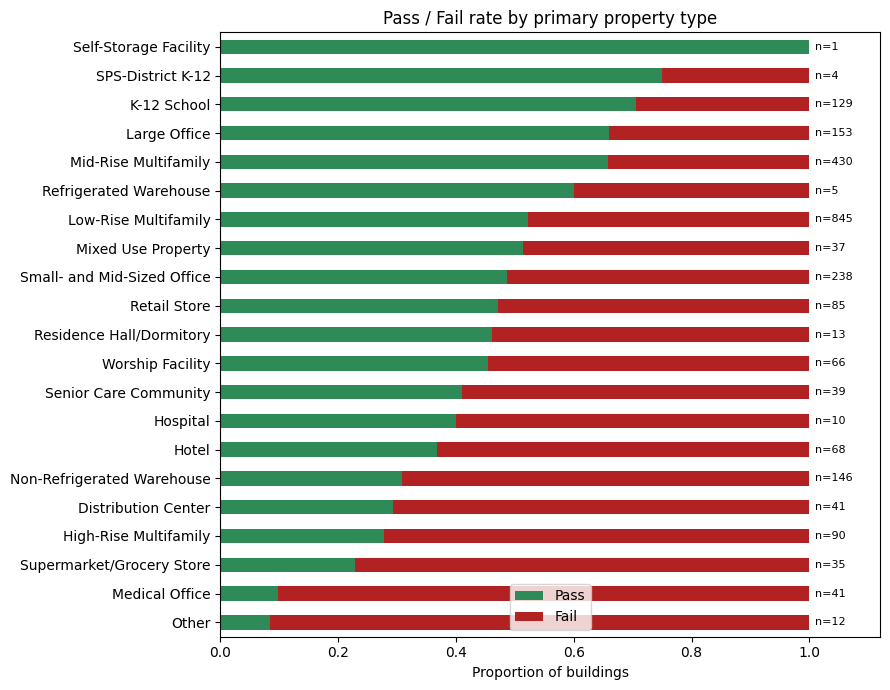

In [31]:
# Visualize Pass / Fail rate by primary property type (normalize to capture rate)
rate = pd.crosstab(df['PrimaryPropertyType'], df['ENERGYSTARCertification'], normalize='index').sort_values('Pass')
counts = df['PrimaryPropertyType'].value_counts()

ax = rate[['Pass', 'Fail']].plot(kind='barh', stacked=True, figsize=(9, 7),
                                 color={'Pass': 'seagreen', 'Fail': 'firebrick'})
ax.set_xlim(0, 1.12)
ax.set_xlabel('Proportion of buildings'); 
ax.set_ylabel('')
ax.set_title('Pass / Fail rate by primary property type')

# Annotate sample size n at the end of each bar, so small categories aren't over-read
for i, t in enumerate(rate.index):
    ax.text(1.01, i, f'n={counts[t]}', va='center', fontsize=8)

ax.legend(loc='lower center')
plt.tight_layout(); 
plt.show()

In [32]:
# Building-only features: drop the energy / EUI / GHG columns, keep physical characteristics
energy_cols = ['SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SteamUse(kBtu)',
               'Electricity(kBtu)', 'NaturalGas(kBtu)', 'OtherFuelUse(kBtu)',
               'GHGEmissions(MetricTonsCO2e)', 'GHGEmissionsIntensity(kgCO2e/ft2)']

# Reuse the SAME train/test rows as the full classification models for a clean comparison
Xbo_train = Xc_train.drop(columns=energy_cols)
Xbo_test  = Xc_test.drop(columns=energy_cols)

bo_cat = Xbo_train.select_dtypes('object').columns.tolist()
bo_num = Xbo_train.select_dtypes('number').columns.tolist()

# Same preprocessing as before
def make_bo_preprocess():
    numeric = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('power',  PowerTransformer(method='yeo-johnson', standardize=True)),
    ])
    column_tf = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), bo_cat),
        ('num', numeric, bo_num),
    ])
    return Pipeline([
        ('group', RareCategoryGrouper(columns=['PrimaryPropertyType'], min_count=15)),
        ('ct', column_tf),
    ])

In [33]:
# Building-only Logistic Regression (same as full model)
bo_logreg = Pipeline([('prep', make_bo_preprocess()),
                      ('model', LogisticRegression(max_iter=1000))])
bo_logreg.fit(Xbo_train, yc_train)

pass_prob = list(bo_logreg.classes_).index('Pass')
bo_log_pred  = bo_logreg.predict(Xbo_test)
bo_log_proba = bo_logreg.predict_proba(Xbo_test)[:, pass_prob]

bo_log_metrics = {
    'Accuracy': accuracy_score(yc_test, bo_log_pred),
    'Precision': precision_score(yc_test, bo_log_pred, pos_label='Pass'),
    'Recall': recall_score(yc_test, bo_log_pred, pos_label='Pass'),
    'F1': f1_score(yc_test, bo_log_pred, pos_label='Pass'),
    'ROC-AUC': roc_auc_score(yc_test_pass, bo_log_proba),
}
bo_log_metrics

{'Accuracy': 0.6144578313253012,
 'Precision': 0.6263736263736264,
 'Recall': 0.6551724137931034,
 'F1': 0.6404494382022472,
 'ROC-AUC': 0.6476550754158786}

In [34]:
# Building-only Random Forest (same as full model, including min_samples_leaf=10 to limit overfitting)
bo_rf = Pipeline([('prep', make_bo_preprocess()),
                  ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=10, random_state=42))])
bo_rf.fit(Xbo_train, yc_train)

pass_prob = list(bo_rf.classes_).index('Pass')
bo_rf_pred  = bo_rf.predict(Xbo_test)
bo_rf_proba = bo_rf.predict_proba(Xbo_test)[:, pass_prob]

bo_rf_metrics = {
    'Accuracy': accuracy_score(yc_test, bo_rf_pred),
    'Precision': precision_score(yc_test, bo_rf_pred, pos_label='Pass'),
    'Recall': recall_score(yc_test, bo_rf_pred, pos_label='Pass'),
    'F1': f1_score(yc_test, bo_rf_pred, pos_label='Pass'),
    'ROC-AUC': roc_auc_score(yc_test_pass, bo_rf_proba),
}
bo_rf_metrics

{'Accuracy': 0.6044176706827309,
 'Precision': 0.6311475409836066,
 'Recall': 0.5900383141762452,
 'F1': 0.6099009900990099,
 'ROC-AUC': 0.6881032057810758}

In [35]:
# Compare metrics from full-feature vs building-only models
metrics_comparison = pd.DataFrame({
    'Logistic (full)': log_metrics,
    'Logistic (building-only)': bo_log_metrics,
    'Random Forest (full)': rf_metrics,
    'Random Forest (building-only)': bo_rf_metrics,
}).round(3)
metrics_comparison

,Logistic (full),Logistic (building-only),Random Forest (full),Random Forest (building-only)
Accuracy,0.801,0.614,0.821,0.604
Precision,0.798,0.626,0.812,0.631
Recall,0.831,0.655,0.858,0.590
F1,0.814,0.640,0.834,0.610
ROC-AUC,0.874,0.648,0.891,0.688


In [36]:
# Building-only logistic coefficients
bo_feature_names = bo_logreg.named_steps['prep'].named_steps['ct'].get_feature_names_out()
bo_coef = pd.DataFrame({'Predictor': bo_feature_names,
                        'coefficient': bo_logreg.named_steps['model'].coef_[0].round(4)})
bo_coef.sort_values('coefficient', key=abs, ascending=False, ignore_index=True).head(15)

,Predictor,coefficient
0,cat__BuildingType_SPS-District K-12,1.2482
1,cat__PrimaryPropertyType_Medical Office,-1.2064
2,cat__PrimaryPropertyType_Large Office,0.9230
3,cat__BuildingType_Multifamily HR (10+),-0.8731
4,cat__Neighborhood_CENTRAL,-0.6664
5,cat__BuildingType_Nonresidential COS,-0.6493
6,cat__PrimaryPropertyType_K-12 School,0.6491
7,cat__Neighborhood_MAGNOLIA / QUEEN ANNE,0.6301
8,cat__Neighborhood_SOUTHEAST,-0.6016
9,cat__BuildingType_Multifamily LR (1-4),0.5530


In [37]:
# Building-only Random Forest feature importances
bo_rf_names = bo_rf.named_steps['prep'].named_steps['ct'].get_feature_names_out()
bo_importance = pd.DataFrame({'Predictor': bo_rf_names,
                              'importance': bo_rf.named_steps['model'].feature_importances_.round(4)})
bo_importance.sort_values('importance', ascending=False, ignore_index=True).head(15)

,Predictor,importance
0,num__building_age,0.1310
1,num__PropertyGFABuilding(s),0.1117
2,num__PropertyGFATotal,0.1115
3,num__LargestPropertyUseTypeGFA,0.1053
4,num__PropertyGFAParking,0.0728
5,num__NumberofFloors,0.0596
6,cat__Neighborhood_MAGNOLIA / QUEEN ANNE,0.0411
7,cat__BuildingType_Multifamily MR (5-9),0.0391
8,cat__BuildingType_SPS-District K-12,0.0383
9,cat__PrimaryPropertyType_Mid-Rise Multifamily,0.0364


**Full Features vs Building Only Analysis**
- **Performance:** as expected, there is a drop in performance since the score is largely derived from energy features. The drop in accuracy (~0.80 with full features down to ~0.61 with building only) reflects the share of predictive power that came from *how the building uses energy* rather than *how it's built*. What remains is what an owner could anticipate from physical attributes alone.

- **Logistic coefficients:** In the full model, the `Supermarket/Grocery Store` coefficient was strongly positive, but that was conditional on energy use (aka, after energy use is accounted for, being a supermarket is associated with a higher score). In plain terms, the regression model showed that for a given absolute energy intensity, a supermarket should score higher than, for example, a school would at the same intensity. This means the Energy Star score is property-type normalized (supermarkets are expected to have higher energy use so other property types would be more strongly penalized at the same level). With the energy features removed, that confounder is gone, so the building-only coefficients move back toward the raw pass-rate ordering of property types (e.g., schools now show higher odds of passing than supermarkets).

- **Random Forest feature importances:** In the full model the energy features dominate (`SourceEUI` and `SiteEUI` alone account for the top importances, as expected). Removing the energy columns redistributes that importance onto the physical features: `building_age` becomes the single most important predictor, followed by a tight cluster of size measures (`LargestPropertyUseTypeGFA`, `PropertyGFABuilding(s)`, `PropertyGFATotal`). Interestingly, age had a near-zero coefficient in the logistic model, highlighting that there is a non-linear relationship (U-shaped) with the pass rate that logistic regression cannot capture with a single linear age terms. This is visualized in the chart below.

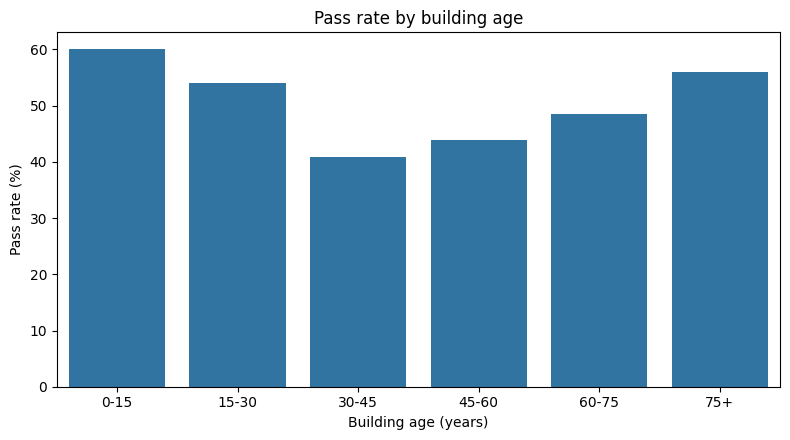

In [38]:
# Visualize pass rate by building age to confirm the non-linear (U-shaped) relationship
# Bin age into bands and compute the pass rate within each band
age_bins   = [0, 15, 30, 45, 60, 75, 200]
age_labels = ['0-15', '15-30', '30-45', '45-60', '60-75', '75+']
ageband = pd.cut(df['building_age'], bins=age_bins, labels=age_labels, right=False)

by_age = (df.assign(ageband=ageband, is_pass=df['ENERGYSTARCertification'].eq('Pass'))
            .groupby('ageband', observed=True)['is_pass']
            .agg(pass_rate='mean', n='size'))

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=by_age.index, y=by_age['pass_rate'] * 100)

ax.set_xlabel('Building age (years)')
ax.set_ylabel('Pass rate (%)')
ax.set_title('Pass rate by building age')
plt.tight_layout()
plt.show()

### Logistic Regression vs Random Forest

**Predictive performance:** Random Forest consistently performed better than Logistic Regression, though not by much. This makes sense because while there are some non-linear relationships that a linear model could not capture, the ENERGY STAR Score (and certification) is largely driven by the energy-use features, and that signal is strong enough for both a linear and a non-linear model to capture most of it.

**Feature importance:** Random Forest was able to capture feature importances (like building age) that Logistic Regression missed due to non-linear relationships. This was exaggerated in the building-only model where the non-linear structure lives, as could be seen by the widening gap in performance metrics. That being said, the tradeoff is that Random Forest loses the clear interpretability of HOW the feature is impacting the score